Iris dataset
It is a small dataset so it allows fast iteration. Features are cleaned, no duplicates,
no missing values so it requires minimal preprocessing.
Target classes are well-separated, this allows a good intuition
It is a dataset perfect for comparing algorithms, understanding decision boundaries  and 
learning ML workflows

Loading the dataset

In [3]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
df = iris.frame
print(df)


     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8   

     target  
0         0  

Basic structural inspection

In [5]:
#Shape and columns
# print(f"df.shape" +df.shape)
# print(f"df.columns" +df.columns)
#Preview
print(df.head())
print(df.tail())
#types
df.dtypes

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0        

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int32
dtype: object

Summary statistics

In [7]:
print(df.describe())

#To reveal: feature ranges,scale differences,class imbalance
df['target'].value_counts()

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


target
0    50
1    50
2    50
Name: count, dtype: int64

Missing values and duplicates

In [11]:
print(df.isnull().sum())
print(df.duplicated().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64
1


Target mapping

In [13]:
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))

Features distribution
look for:
- skewness: Whether data is pulled more to the left or right rather than being symmetric.
it matters because: 
Many statistical methods assume normal (symmetric) distributions.
Mean and standard deviation become misleading in skewed data.
The median may be a better summary than the mean. 

- multimodal distributions:The data may contain multiple subgroups or processes.
Why it matters:
A single average hides important structure.
Indicates the data might be a mixture of populations

- outliers:Unusual observations that differ strongly from the rest.
Can distort means, regressions, and variance estimates.
May represent:
Data errors
Rare but important events
New or unexpected phenomena

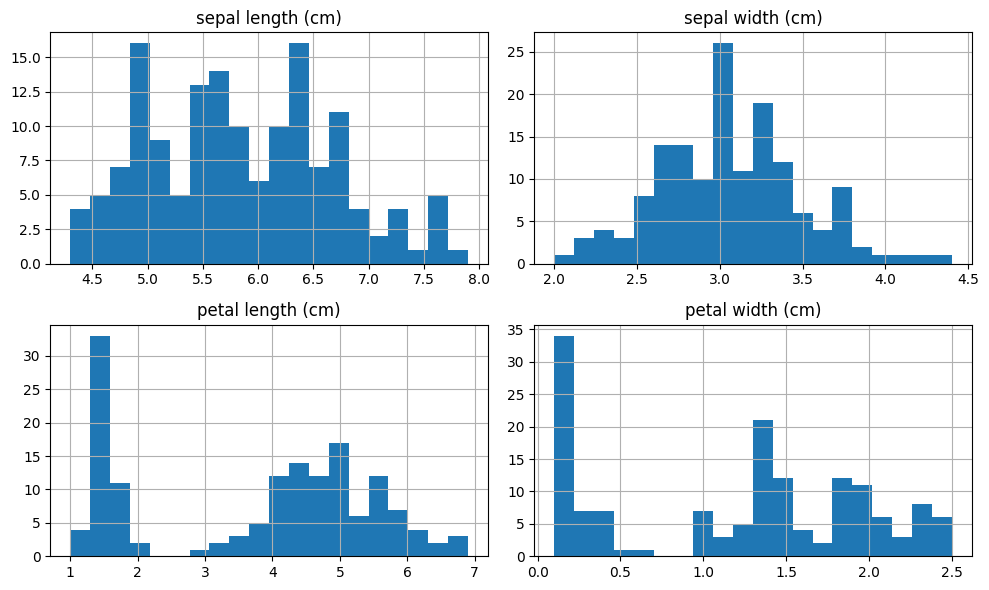

In [9]:
import matplotlib.pyplot as plt

df.drop(columns=['target']).hist(
    figsize=(10, 6), bins=20
)
plt.tight_layout()
plt.show()


These checks matter for:
-Choose the right statistical methods
-Decide whether to clean, transform, or segment data
-Avoid false conclusions caused by violated assumptions
-Build more reliable models and interpretations

Class-wise features distribution

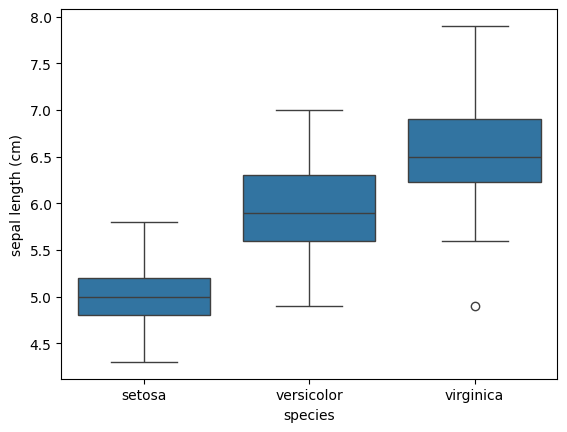

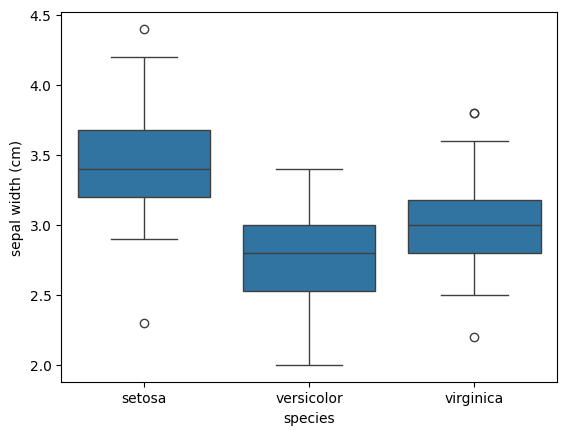

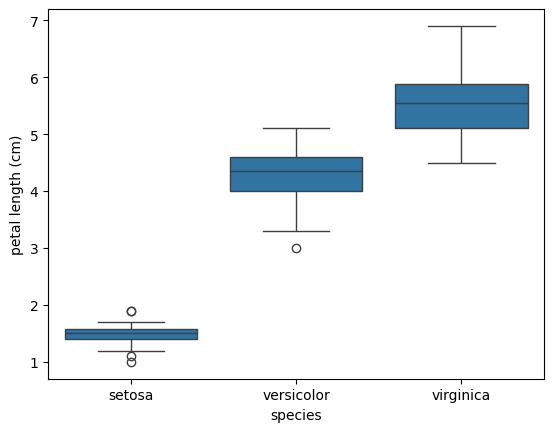

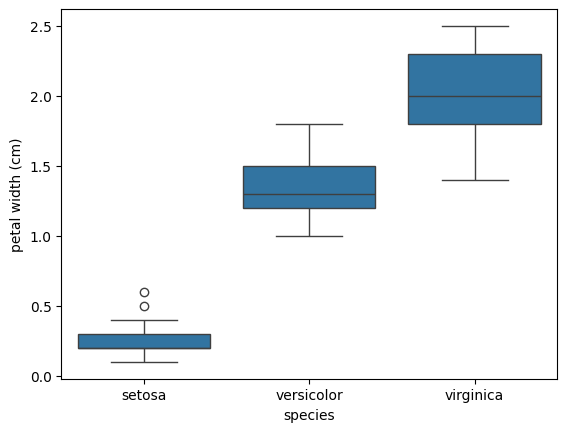

In [14]:
import seaborn as sns

for col in df.columns[:-2]:
    sns.boxplot(x='species', y=col, data=df)
    plt.show()


Pairplot for feature relationship

This is extremely powerful for:
separability intuition
linear vs nonlinear boundaries
feature redundancy

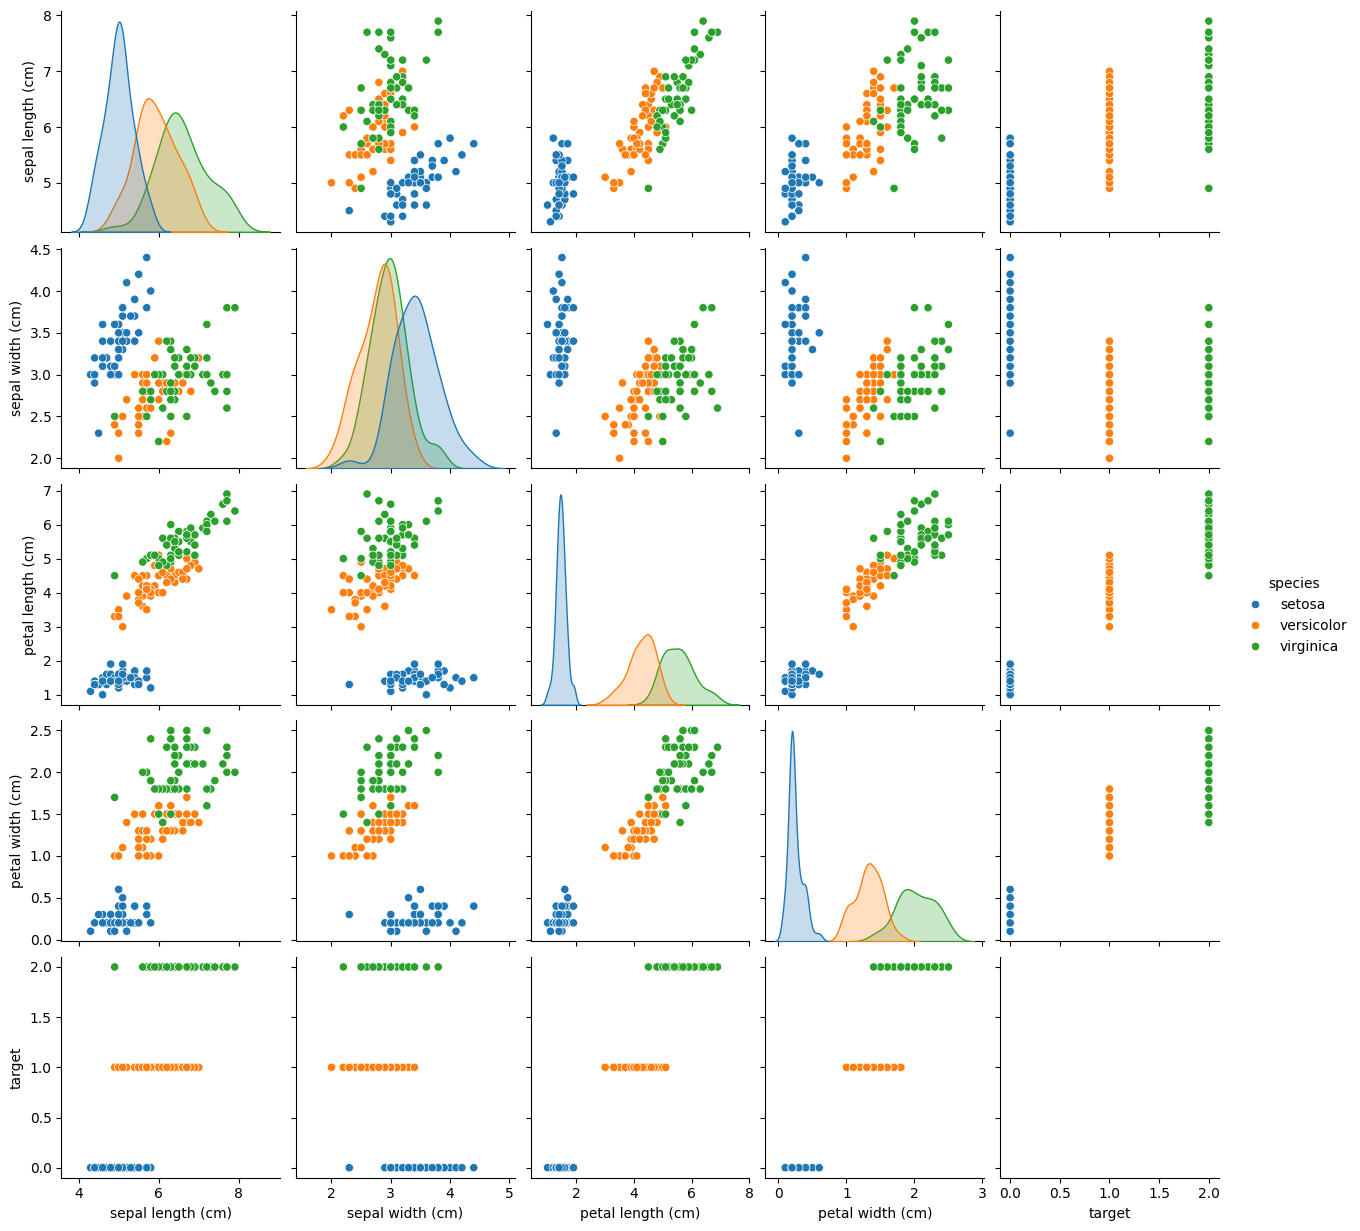

In [15]:
sns.pairplot(df, hue='species')
plt.show()

Correlation analysis

- detect highly correlated features
- anticipate multicollinearity issues

In [ ]:
corr = df.drop(columns=['target', 'species']).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()


Outlier inspection

In [16]:
from scipy.stats import zscore

z_scores = df.drop(columns=['target', 'species']).apply(zscore)
outliers = (abs(z_scores) > 3).sum()
print(outliers)

sepal length (cm)    0
sepal width (cm)     1
petal length (cm)    0
petal width (cm)     0
dtype: int64


Minimal cleaning 

For Iris, cleaning is minimal. In general:
scale features if needed
encode categorical variables
remove or cap extreme outliers
normalize if model requires it

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop(columns=['target', 'species']))


Final  dataset

In [18]:
X = df.drop(columns=['target', 'species'])
y = df['target']


Train/test split

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


Logistic regression

In [20]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)


In [21]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9666666666666667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



Decision Tree

In [22]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)


Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)


GradientBoost

In [25]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)


SVM

In [32]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf"))
])

svm_pipeline.fit(X_train, y_train)
svm_pred = svm_pipeline.predict(X_test)


Compare models

In [27]:
models = {
    "Logistic Regression": log_reg,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "SVM": svm
}

from sklearn.metrics import accuracy_score

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name}: {acc:.3f}")


Logistic Regression: 0.967
Decision Tree: 0.933
Random Forest: 0.900
Gradient Boosting: 0.967
SVM: 0.967


Cross-validation

In [28]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(f"{name}: mean={scores.mean():.3f}, std={scores.std():.3f}")


Logistic Regression: mean=0.973, std=0.025
Decision Tree: mean=0.953, std=0.034
Random Forest: mean=0.967, std=0.021
Gradient Boosting: mean=0.960, std=0.033
SVM: mean=0.967, std=0.021


Confusion matrix

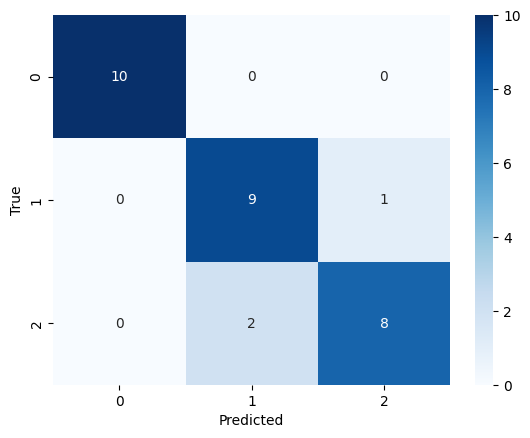

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


Decision Boundary Visualization (2D)

Reduce to  2D using PCA

Why PCA helps
Removes correlation
Reduces noise
Makes boundaries interpretable
Often improves generalization

In [35]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data
y = iris.target

# Scale first (important for PCA)
X_scaled = StandardScaler().fit_transform(X)

# Reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)


Train a classifier

In [36]:
from sklearn.svm import SVC

clf = SVC(kernel="rbf", gamma=1, C=1)
clf.fit(X_train, y_train)

SVC(C=1, gamma=1)

In [37]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2)),
    ("clf", SVC(kernel="rbf", C=1, gamma=1))
])

pipeline.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=2)),
                ('clf', SVC(C=1, gamma=1))])

Plot decision boundaries

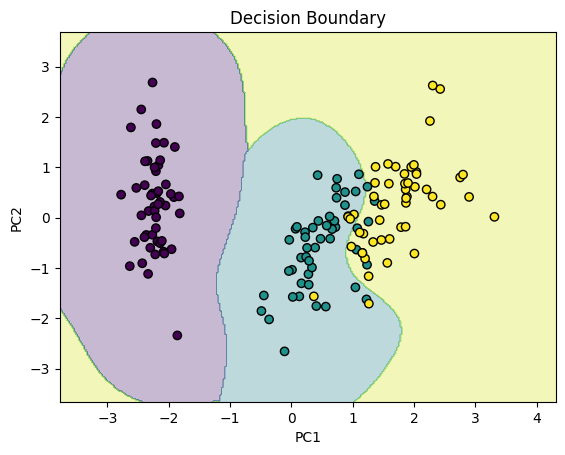

In [38]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Decision Boundary")
    plt.show()

plot_decision_boundary(clf, X_pca, y)


Underfitting
Low train accuracy
Low test accuracy
Model too simple → high bias

In [39]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_under = DecisionTreeClassifier(max_depth=1)
dt_under.fit(X_train, y_train)

print("Train accuracy:", accuracy_score(y_train, dt_under.predict(X_train)))
print("Test accuracy:", accuracy_score(y_test, dt_under.predict(X_test)))


Train accuracy: 0.6666666666666666
Test accuracy: 0.6666666666666666


Overfitting
Very high train accuracy (often 100%)
Lower test accuracy
Model memorizes data → high variance

In [41]:
dt_over = DecisionTreeClassifier(max_depth=None)
dt_over.fit(X_train, y_train)

print("Train accuracy:", accuracy_score(y_train, dt_over.predict(X_train)))
print("Test accuracy:", accuracy_score(y_test, dt_over.predict(X_test)))


Train accuracy: 1.0
Test accuracy: 0.8666666666666667


In [40]:
dt_good = DecisionTreeClassifier(max_depth=3)
dt_good.fit(X_train, y_train)

print("Train accuracy:", accuracy_score(y_train, dt_good.predict(X_train)))
print("Test accuracy:", accuracy_score(y_test, dt_good.predict(X_test)))

Train accuracy: 0.9416666666666667
Test accuracy: 0.8666666666666667


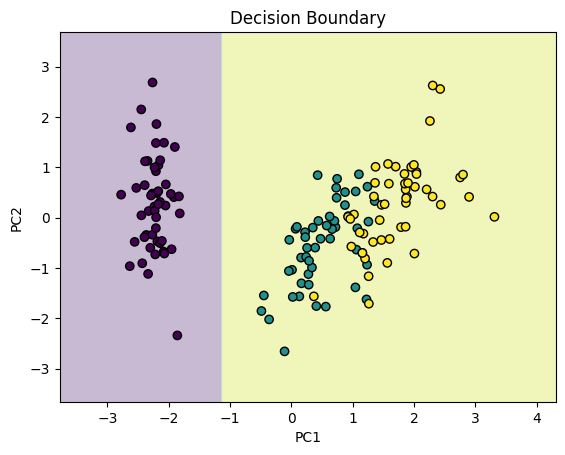

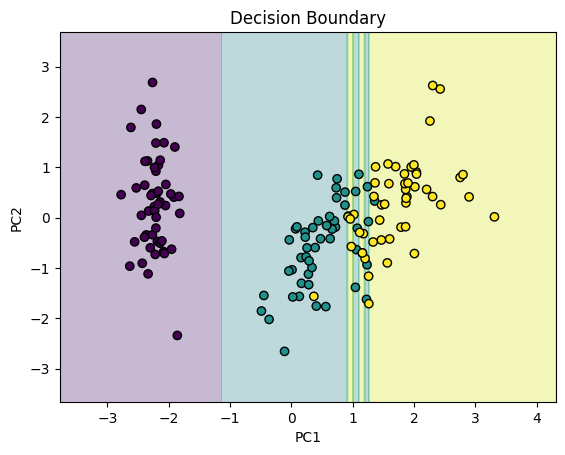

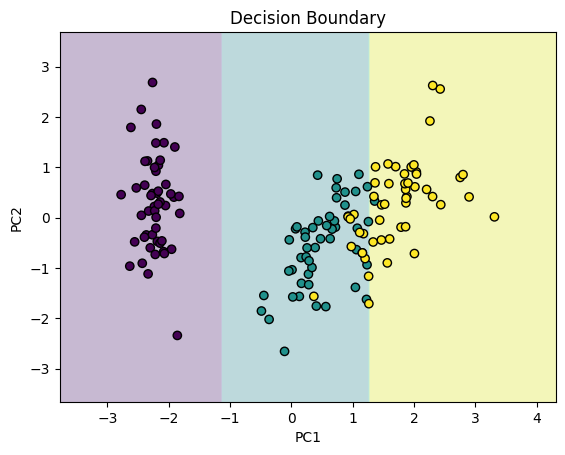

In [42]:
plot_decision_boundary(dt_under, X_pca, y)
plot_decision_boundary(dt_over, X_pca, y)
plot_decision_boundary(dt_good, X_pca, y)